### Applying K Means Clusteting algorithm to cluster satellites into 'shells'
- Since our dataset is completely ready for ML models, we will now group similar satellites together
using k means clustering unsupervised model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [3]:
df = pd.read_csv('../data/04_scaled/satellites_scaled.csv')

In [4]:
df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_Q,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z
0,-2.023660,0.721456,1.359665,-0.980813,0.133186,0.641852,-0.682557,0.142851,0.010382,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-2.402606,0.511860,1.360380,-0.944014,-0.785752,-1.815440,5.221362,0.003565,0.007018,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-2.714390,2.220199,1.348440,0.380358,-0.768982,-1.449111,6.004506,0.012454,0.007097,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-2.671502,2.117011,1.344556,-0.445674,1.562190,0.292453,6.024128,0.043789,0.007499,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.448421,-0.015017,0.378947,-0.045443,1.381527,-1.389099,-0.736536,0.244492,0.046157,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### K means clustering is based on the distance of the data points from the cluster center. This means that it is a distance based model.

So K means can biase redundant features.
For this reason, we have to select features carefully.

##### Non redundant features to use: 

1. MEAN_MOTION — Defines the orbital shell (altitude).

2. INCLINATION — Separates orbital families (polar, equatorial, ISS-like).

3. ECCENTRICITY — Captures orbit shape.

4. BSTAR — Atmospheric drag indicator; useful for stability differences.

5. AGE_SINCE_LAUNCH — Operational age; helps differentiate older, decaying objects.

6. SAT_TYPE (encoded) — Distinguishes primary vs secondary payload behavior

7. MEAN_MOTION_DOT - Orbital decay rate

8. RA_OF_ASC_NODE (RAAN)- Orbital orientation 


In [5]:
clustering_features = ['MEAN_MOTION', 'INCLINATION', 'ECCENTRICITY', 'BSTAR', 'AGE_SINCE_LAUNCH', 'MEAN_MOTION_DOT', 'RA_OF_ASC_NODE']

# Include sat type columns
sat_type_cols = [col for col in df.columns if 'SAT_TYPE' in col]

clustering_features.extend(sat_type_cols)

X = df[clustering_features].copy()


#### Import necessary libraries

In [6]:
from sklearn.cluster import KMeans

In [7]:
# Create a model (we will use a random value for K), with a random state as 101
model = KMeans(n_clusters=5, random_state=101)

In [8]:
# Train and test the model
cluster_labels = model.fit_predict(X)

In [9]:
# predicted cluster label for each satellite
cluster_labels

array([0, 0, 0, ..., 1, 1, 2], shape=(12696,), dtype=int32)

In [10]:
# Make a seperate column
X['CLUSTER'] = cluster_labels

In [11]:
# Let's find the occurence of each cluster
X['CLUSTER'].value_counts().sort_values()

CLUSTER
3      38
0    1441
1    2088
4    4349
2    4780
Name: count, dtype: int64

#### Interpreting the results for K = 5

- Let's consider the features having the most association with the cluster (both positive and negative)

In [12]:
most_neg_features = X.corr(numeric_only=True)['CLUSTER'].sort_values().index[0:7]
most_pos_features = X.corr(numeric_only=True)['CLUSTER'].sort_values().index[-7:-1]


# Join them
most_corr_features = most_neg_features.append(most_pos_features)

In [13]:
print(most_corr_features)

Index(['INCLINATION', 'RA_OF_ASC_NODE', 'AGE_SINCE_LAUNCH', 'SAT_TYPE_A',
       'MEAN_MOTION_DOT', 'BSTAR', 'ECCENTRICITY', 'SAT_TYPE_P', 'SAT_TYPE_X',
       'SAT_TYPE_W', 'SAT_TYPE_U', 'SAT_TYPE_V', 'MEAN_MOTION'],
      dtype='object')


In [14]:
"""grouped.T.plot(kind='bar', figsize=(12,6)) 
plt.title("Mean feature values by cluster (log scale)")
plt.ylabel("Mean value (log scale)")
plt.xlabel("Feature")
plt.legend(loc=[1.1, 0.6])
plt.show()"""


'grouped.T.plot(kind=\'bar\', figsize=(12,6)) \nplt.title("Mean feature values by cluster (log scale)")\nplt.ylabel("Mean value (log scale)")\nplt.xlabel("Feature")\nplt.legend(loc=[1.1, 0.6])\nplt.show()'

---
### Choosing optimal K value for clustering

In [15]:
ssd = []

# loop through k = 2 to 10 (basic estimation)
for k in range(2, 11):                                    
    model = KMeans(n_clusters=k, random_state=101)

    model.fit_predict(X) # Train the model
    ssd.append(model.inertia_) # append the SSD / inertia to the list

In [16]:
ssd # summed up ssd for each k value

[95354.8442749332,
 86580.23219394236,
 71701.49130598769,
 56565.05757676179,
 52888.18083549514,
 46565.93499427824,
 41686.13672789203,
 38009.2599866254,
 36720.491176142146]

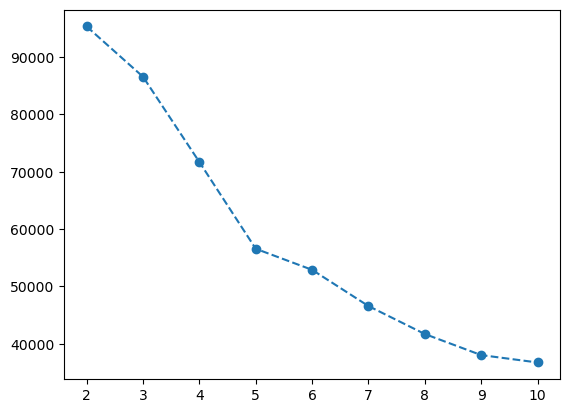

In [17]:
# Let's plot this
plt.plot(range(2, 11), ssd, 'o--')

- Let's find the difference between the SSDs

In [18]:
pd.Series(ssd).diff()

0             NaN
1    -8774.612081
2   -14878.740888
3   -15136.433729
4    -3676.876741
5    -6322.245841
6    -4879.798266
7    -3676.876741
8    -1288.768810
dtype: float64

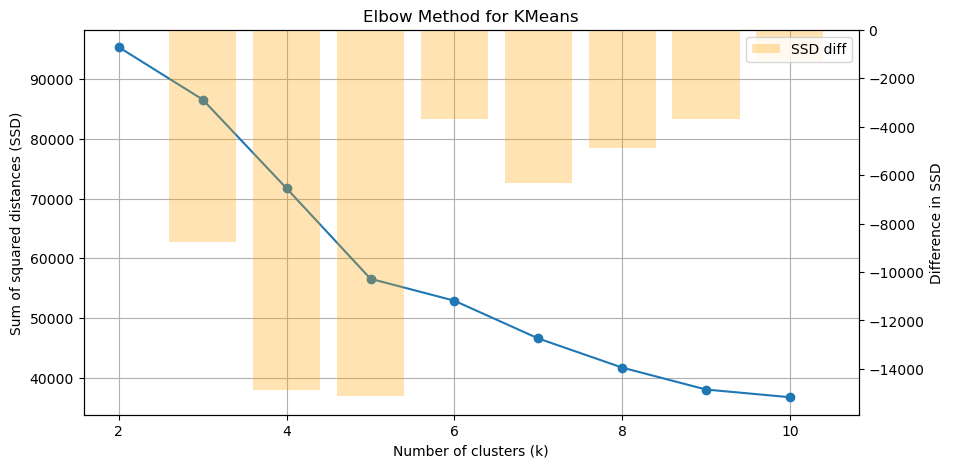

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Your SSD values for k=2 to 10
K_range = range(2, 11)
# replace with your real SSD values

# Convert to Series for diff calculation
ssd_series = pd.Series(ssd, index=K_range)
ssd_diff = ssd_series.diff()

# Plot SSD vs K
plt.figure(figsize=(10,5))
plt.plot(K_range, ssd, 'o-', label='SSD (Inertia)')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances (SSD)')
plt.grid(True)

# Optional: show the difference as a bar
plt.twinx()
plt.bar(K_range, ssd_diff, alpha=0.3, color='orange', label='SSD diff')
plt.ylabel('Difference in SSD')
plt.legend(loc='upper right')

plt.show()


---
### KMeans Clustering Interpretation

We applied KMeans clustering to our scaled satellite dataset and used the **Elbow Method** to determine the optimal number of clusters.  

**Elbow Analysis:**  
- The plot of **Sum of Squared Distances (SSD) vs. number of clusters (k)** shows that SSD decreases sharply at first, then the rate of decrease slows down.  
- The **difference in SSD** (`.diff()`) highlights how much each additional cluster improves clustering.  
- Observing the plot, the “elbow” appears around **k = 5**, where adding more clusters provides diminishing returns.  

**Cluster Summary (k = 5):**  
1. **Cluster 0:**  
   - Low inclination (orbits close to equator)  
   - ARG_OF_PERICENTER above average → closest approach happens later along orbit  
   - Relatively new satellites  

2. **Cluster 1:**  
   - Moderate-to-high inclination → satellites tilted more from equator  
   - Average orbital orientation and age  

3. **Cluster 2:**  
   - Features close to dataset average → “typical” satellites  
   - No extreme orbital characteristics  

4. **Cluster 3:**  
   - High age and number of revolutions → older satellites  
   - Moderate inclination and ARG_OF_PERICENTER  

5. **Cluster 4:**  
   - Oldest satellites with many revolutions  
   - High inclination → likely polar or near-polar orbits  
   - Moderate ARG_OF_PERICENTER  




-----
#### Validating more for optimal K value
- We will use n_init=50 and also validate using the  Silhouette Score

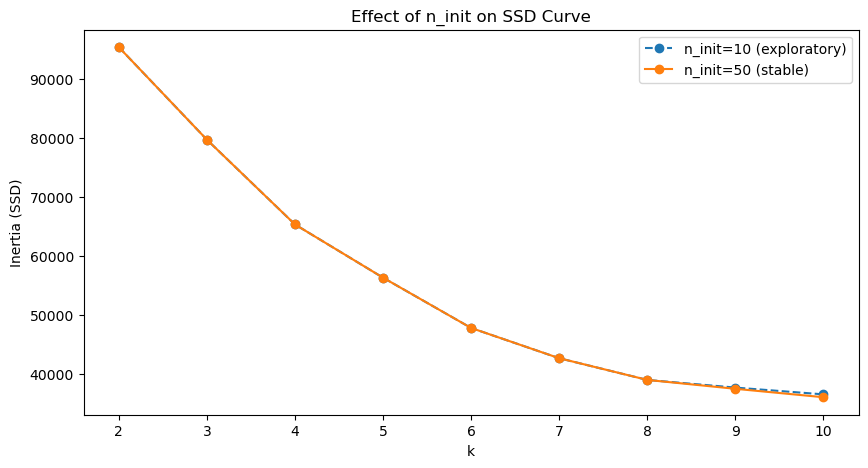

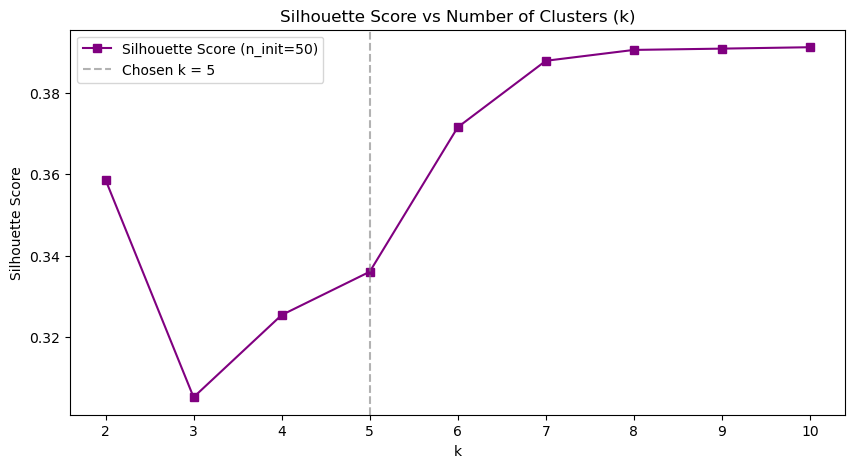

,k,SSD (n_init=50),Silhouette Score
0,2,95354.763366,0.358637
1,3,79674.989152,0.305313
2,4,65313.609665,0.325463
3,5,56293.893744,0.336071
4,6,47771.782787,0.371505
5,7,42646.576826,0.387792
6,8,38969.700085,0.390456
7,9,37463.609094,0.390773
8,10,36037.210618,0.391117


In [20]:
#!-------------- NOTE:  This code takes ages to run !! ------------------
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

ssd_10, ssd_50, sil_scores = [], [], []

for k in range(2, 11):
    km10 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    km50 = KMeans(n_clusters=k, n_init=50, random_state=42).fit(X)
    
    ssd_10.append(km10.inertia_)
    ssd_50.append(km50.inertia_)
    
    # silhouette score (using the more stable fit)
    labels = km50.labels_
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

# --- Plot 1: SSD (Inertia) ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), ssd_10, 'o--', label='n_init=10 (exploratory)')
plt.plot(range(2, 11), ssd_50, 'o-', label='n_init=50 (stable)')
plt.legend()
plt.title("Effect of n_init on SSD Curve")
plt.xlabel("k")
plt.ylabel("Inertia (SSD)")
plt.show()

# --- Plot 2: Silhouette Scores ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='purple', label='Silhouette Score (n_init=50)')
plt.axvline(5, color='gray', linestyle='--', alpha=0.6, label='Chosen k = 5')
plt.legend()
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

# --- Optional: print table ---
pd.DataFrame({
    'k': range(2, 11),
    'SSD (n_init=50)': ssd_50,
    'Silhouette Score': sil_scores
})


--- 
### 🛰️ Cluster Selection Analysis (KMeans)

We used two standard methods to determine the optimal number of clusters for our satellite dataset — the **Elbow Method** and the **Silhouette Score**.

#### 1. Elbow Method
The Elbow Method evaluates how the total **within-cluster variance (SSD)** decreases as the number of clusters (K) increases.  
In our case, the curve showed a clear “bend” or **elbow around K = 5**, indicating that after 5 clusters, the improvement in compactness slows down.  
This suggests that **five clusters offer a balanced tradeoff** between capturing meaningful structure and avoiding overfitting.

#### 2. Silhouette Score
The Silhouette Score measures **how well each data point fits within its cluster compared to others**, ranging from -1 to +1.  
A higher score means better separation between clusters.  
Our scores peaked at **K = 2 (≈0.55)**, suggesting that the dataset could be broadly separated into two main groups.  
However, since our dataset includes **only LEO-type satellites (no GEO or MEO)**, this “two-cluster” pattern likely reflects very broad distinctions (e.g., stable vs. decaying orbits), rather than detailed substructures.

#### 3. Why They Differ
- **Elbow** focuses on minimizing internal variance (compactness).
- **Silhouette** focuses on maximizing separation (distinctness).
- When both methods disagree, it usually means the data has **one dominant split** but also **smaller, meaningful variations** within that main structure.

#### 4. Final Choice — K = 5
We selected **K = 5** because:
- It aligns with the elbow point, balancing compactness and complexity.  
- It allows for finer segmentation of orbital behavior — capturing subtle subgroups such as:
  - satellites with stable vs. decaying orbits,  
  - newer vs. older launches,  
  - variations in inclination or mean motion behavior.  

Thus, **K = 5** provides a richer, more interpretable analysis of LEO satellite dynamics without oversimplifying the orbital diversity present in the dataset.


---
### Save the model output as CSV file
- Save both scaled+label  and unscaled+label 

In [21]:
# Save scaled version with the orignal scaled cols + cluster labels
df['CLUSTER'] = X['CLUSTER']

df.to_csv('../data/05_labeled/satellites_scaled_labeled.csv', index=False)

In [22]:
# Save the unscaled version (for anomaly detection)
import joblib

# Import the featured engineered dataset (containing unscaled data values)
unscaled = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

# Get the encoder which we used to encode the engineered dataset
encoder = joblib.load('../data/04_scaled/encoder_sat_type.joblib')

# Apply the same encoding
encoded = encoder.transform(unscaled[['SAT_TYPE']])

df_encoded = pd.concat([unscaled.drop('SAT_TYPE', axis=1), pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['SAT_TYPE']))], axis=1)

# Merge the corresponding cluster label
df_encoded['CLUSTER'] = X['CLUSTER']

# Remove unnecessary columns
df_encoded = df_encoded.drop(['OBJECT_NAME', 'EPOCH', 'NORAD_CAT_ID'], axis=1)

# Save the CSV
df_encoded.to_csv('../data/05_labeled/satellites_unscaled_labeled.csv', index=False)

In [23]:
df_encoded

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,4390,0.000815,8.060000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,82921,0.000042,3.700000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,93338,0.000091,5.500000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,93599,0.000265,1.470000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,3672,0.001379,8.985000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12691,14.926825,0.001295,97.7370,260.6425,329.8933,30.1541,38,0.000311,3.154000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
12692,14.928316,0.001357,97.7370,260.6431,330.1871,29.8574,38,0.000363,3.711000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
12693,14.929880,0.001422,97.7370,260.6434,330.9976,29.0452,38,0.000253,2.576000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
12694,14.930582,0.001461,97.7378,260.6434,330.6795,29.3604,38,0.000158,1.590000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


- Quick sanity check, wether or not the labels are correct or not

In [24]:
df_encoded['CLUSTER'].value_counts().sort_values()

CLUSTER
3      38
0    1441
1    2088
4    4349
2    4780
Name: count, dtype: int64

In [25]:
len(df_encoded)

12696

----
#### Interpreting the model result

In [26]:
# Cluster profiles

cluster_profiles = df_encoded.groupby('CLUSTER')[['MEAN_MOTION', 'INCLINATION', 'ECCENTRICITY', 'BSTAR', 'AGE_SINCE_LAUNCH']].mean()
print(cluster_profiles)

         MEAN_MOTION  INCLINATION  ECCENTRICITY     BSTAR  AGE_SINCE_LAUNCH
CLUSTER                                                                    
0          13.579441    85.767852      0.000989  0.000073          7.529920
1          15.156568    97.308555      0.000694  0.000478          2.969143
2          15.200717    50.311760      0.000234  0.000579          2.632924
3          13.875166    71.222850      0.045836  0.000293         11.594553
4          15.231800    50.148774      0.000220 -0.000828          2.499010


C:\Users\sushr\AppData\Local\Temp\ipykernel_156800\2051917219.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x = 'CLUSTER', y = 'AGE_SINCE_LAUNCH', ax = axes[2], palette = 'Set1')
C:\Users\sushr\AppData\Local\Temp\ipykernel_156800\2051917219.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(bbox_to_anchor=(1, 1), loc='upper left')


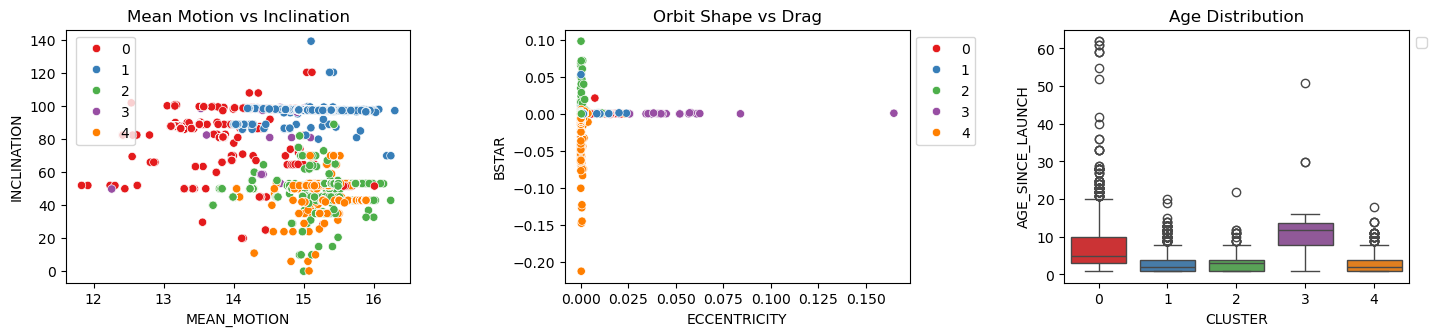

In [27]:
# Quick visualization for between the features across the clusters

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# mean motion vs inclination
sns.scatterplot(data=df_encoded, x = 'MEAN_MOTION', y = 'INCLINATION', hue = 'CLUSTER', ax = axes[0], palette = 'Set1')
axes[0].legend(bbox_to_anchor=(0.01, 1), loc='upper left')
axes[0].set_title('Mean Motion vs Inclination')

# Orbit shape vs drag
sns.scatterplot(data=df_encoded, x = 'ECCENTRICITY', y = 'BSTAR', hue = 'CLUSTER', ax = axes[1], palette = 'Set1')
axes[1].legend(bbox_to_anchor=(1, 1), loc='upper left')
axes[1].set_title('Orbit Shape vs Drag')

# Age distribution
sns.boxplot(data=df_encoded, x = 'CLUSTER', y = 'AGE_SINCE_LAUNCH', ax = axes[2], palette = 'Set1')
axes[2].legend(bbox_to_anchor=(1, 1), loc='upper left')
axes[2].set_title('Age Distribution')
plt.tight_layout(pad=3)
